** Problem Understanding**

This project focuses on detecting fraudulent credit card transactions using machine learning.
Fraud transactions are very rare, so the dataset is highly imbalanced, making this a real-world classification problem.

**Objectives**

1. Detect fraudulent transactions from real-world data.
2. Handle imbalanced dataset using advanced techniques.
3. Perform feature engineering for better model performance.
4. Evaluate model using appropriate metrics like ROC-AUC.
5. Generate insights using visualization


**Import Libraries**

Loaded essential libraries for data processing, visualization, and machine learning

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from math import radians, sin, cos, sqrt, atan2

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

2.**Dataset**

Source: Kaggle Fraud Detection Dataset
Files Used:

fraudTrain.csv

fraudTest.csv


**Key Features:**
Transaction details (amount, category)
Customer details (age, gender)
Location data (latitude, longitude)
Time data (transaction timestamp)
Target variable: is_fraud (0 = Legit, 1 = Fraud)

In [26]:
df_train = pd.read_csv('/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv')
df_test = pd.read_csv('/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv')
print("Train:", df_train.shape)
print("Test:", df_test.shape)


Train: (1296675, 23)
Test: (555719, 23)


In [ ]:
#df_train.head()
#df_test.head()

**3. Basic Data Check**

In [27]:
print(df_train.info())
print(df_test.info())

print(df_train.isnull().sum())
print(df_test.isnull().sum())

print(df_train.describe())
print(df_test.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

4.Data Cleaning

Handled missing values:

Numerical → filled with median

Categorical → filled with mode

Removed duplicate records to avoid bias

In [28]:
num_cols = df_train.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

cat_cols = df_train.select_dtypes(include='object').columns
for col in cat_cols:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

df_train = df_train.drop_duplicates()
#print("✅ Data Cleaned")


**5.Feature Engineering** 

a.Time-Based Features

Converted transaction time into:
   Hour
   Day
   Month
Helps capture behavioral patterns (e.g., fraud at night)


In [29]:
# Time features
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])

df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_test['hour'] = df_test['trans_date_trans_time'].dt.hour

df_train['day'] = df_train['trans_date_trans_time'].dt.day
df_test['day'] = df_test['trans_date_trans_time'].dt.day

df_train ['month']= df_train['trans_date_trans_time'].dt.month
df_test ['month']= df_test['trans_date_trans_time'].dt.month

#df_train[['hour','day','month']].head()

**Age Feature**
Extracted age from date of birth
Helps analyze fraud across age groups

In [30]:
df_train['dob'] = pd.to_datetime(df_train['dob'])
df_test['dob'] = pd.to_datetime(df_test['dob'])

df_train['age'] = 2025 - df_train['dob'].dt.year
df_test['age'] = 2025 - df_test['dob'].dt.year

#df_train[['dob', 'age']].head()

**Distance Feature (Very Important)**

Calculated distance between:

Customer location

Merchant location

Used Haversine formula

In [31]:

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

df_train['distance_km'] = df_train.apply(
    lambda row: calculate_distance(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1
)

df_test['distance_km'] = df_test.apply(
    lambda row: calculate_distance(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1
)

df_train['distance_miles'] = df_train['distance_km'] * 0.621
df_test['distance_miles'] = df_test['distance_km'] * 0.621

**Distance Categorization**

0–50 miles

50–100 miles

100+ miles

Helps identify suspicious transactions far from user location

In [32]:
def distance_category(x):
    if x <= 50:
        return '0-50'
    elif x <= 100:
        return '50-100'
    else:
        return '100+'

df_train['distance_group'] = df_train['distance_miles'].apply(distance_category)
df_test['distance_group'] = df_test['distance_miles'].apply(distance_category)
#print(" Feature engineering completed")

** Drop Unnecessary Columns**
   
Name, address, raw timestamps

Reduces noise and improves model performance

In [33]:
drop_cols = ['Unnamed: 0','first','last','street','trans_date_trans_time','dob']
df_train = df_train.drop(columns=drop_cols, errors='ignore')
df_test = df_test.drop(columns=drop_cols, errors='ignore')

#print(" Columns dropped")

7.Exploratory Data Analysis (EDA)

We analyze data to understand fraud behavior:

a. Fraud Distribution

    Dataset is highly imbalanced (~99% non-fraud)

b. Transaction Amount

    Fraud cases often show unusual or extreme amounts

c. Category Analysis

    Higher fraud in online and miscellaneous transactions

d. Distance Analysis

    Fraud often occurs at larger distances

e. Time Analysis

    Fraud is more common during late-night hours


Goal: Identify patterns before modeling

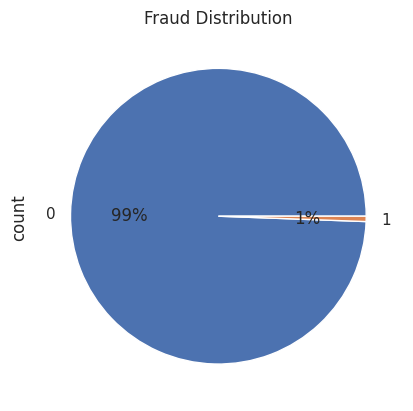

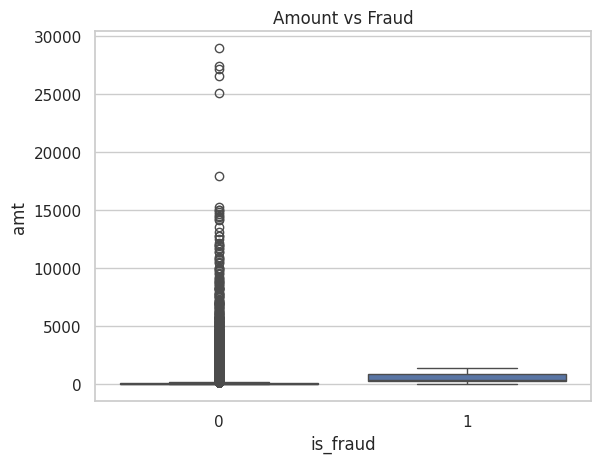

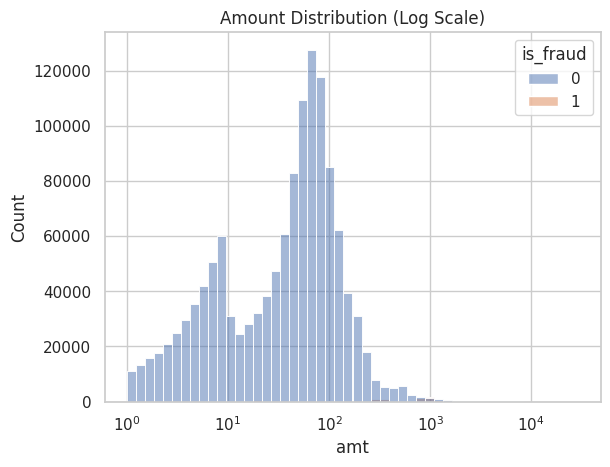

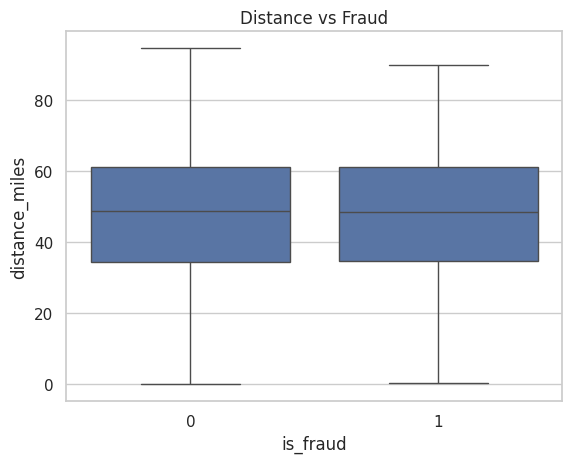

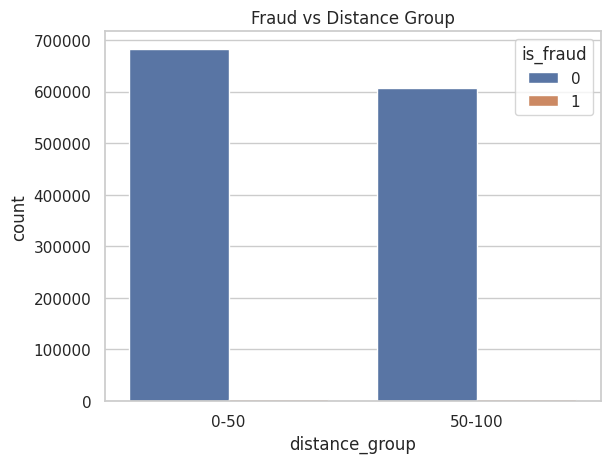

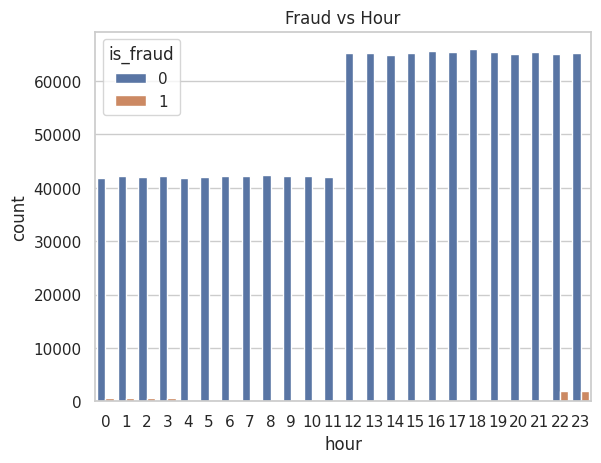

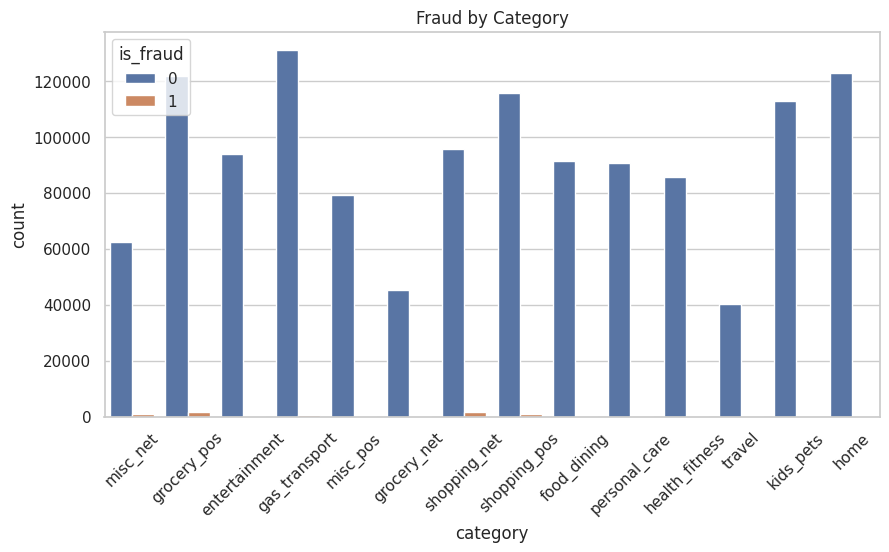

✅ EDA Completed


In [34]:

# Fraud Distribution
df_train['is_fraud'].value_counts().plot.pie(autopct='%0.0f%%')
plt.title("Fraud Distribution")
plt.show()

# Amount vs Fraud (Outliers)
sns.boxplot(x='is_fraud', y='amt', data=df_train)
plt.title("Amount vs Fraud")
plt.show()

# Log scale amount
sns.histplot(data=df_train, x='amt', hue='is_fraud', bins=50, log_scale=True)
plt.title("Amount Distribution (Log Scale)")
plt.show()

# Distance vs Fraud
sns.boxplot(x='is_fraud', y='distance_miles', data=df_train)
plt.title("Distance vs Fraud")
plt.show()

# Distance category
sns.countplot(x='distance_group', hue='is_fraud', data=df_train)
plt.title("Fraud vs Distance Group")
plt.show()

# Time pattern
sns.countplot(x='hour', hue='is_fraud', data=df_train)
plt.title("Fraud vs Hour")
plt.show()

# Category pattern
plt.figure(figsize=(10,5))
sns.countplot(x='category', hue='is_fraud', data=df_train)
plt.xticks(rotation=45)
plt.title("Fraud by Category")
plt.show()

print(" EDA Completed")

8.**Encoding Categorical Features**

Converted categorical variables into numeric format using Label Encoding

Ensured consistent encoding by combining train + test data

In [35]:
df_full = pd.concat([df_train, df_test], axis=0)

cat_cols = df_full.select_dtypes(include='object').columns

from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    df_full[col] = df_full[col].astype(str)
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col])

# Split back
df_train = df_full[:len(df_train)]
df_test = df_full[len(df_train):]

print("Encoding done safely")

Encoding done safely


9.**Train-Test Split**

Separated features (X) and target (y)

Used predefined train and test datasets

In [36]:
#9. SPLIT FEATURES & TARGET
X_train = df_train.drop('is_fraud', axis=1)
y_train = df_train['is_fraud']

X_test = df_test.drop('is_fraud', axis=1)
y_test = df_test['is_fraud']
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1296675, 23)
Test size: (555719, 23)


10.**Feature Scaling**

Applied StandardScaler

Improves model performance and stability

In [37]:
# 10. SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#print(" Scaling done")

11.**Handling Imbalanced Data ( SMOTE)**

Applied SMOTE (Synthetic Minority Oversampling Technique)

Balanced fraud and non-fraud classes

Before SMOTE:

Fraud cases were extremely low (~1%)

After SMOTE:

Balanced dataset improves model learning

In [38]:
# 11. SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))


Before SMOTE: [1289169    7506]
After SMOTE: [1289169 1289169]


12.**Model Building**

Used Random Forest Classifier

Advantages:

Handles non-linear data

Works well with tabular data

Robust to overfitting

In [50]:
# 12. MODEL TRAINING
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_res, y_train_res)

# Random Forest 
rf_model = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# XGBoost 
xgb_model = XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.2, random_state=42)
xgb_model.fit(X_train_res, y_train_res)

print(" All Models Trained")

✅ All Models Trained


13.**Model Evaluation**

Used:

Classification Report:

* Precision
* Recall
* F1-score


ROC-AUC Score:

Best metric for fraud detection

Why ROC-AUC?

Works well for imbalanced datasets

Measures overall model performance

In [40]:

for model, name in zip(
    [log_model, rf_model, xgb_model],
    ["Logistic Regression", "Random Forest", "XGBoost"]
):
    print(f"\n===== {name} =====")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



===== Logistic Regression =====
Accuracy: 0.9683113228088296
ROC-AUC: 0.8497979171128559
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.08      0.74      0.15      2145

    accuracy                           0.97    555719
   macro avg       0.54      0.85      0.57    555719
weighted avg       1.00      0.97      0.98    555719

Confusion Matrix:
 [[536529  17045]
 [   565   1580]]

===== Random Forest =====
Accuracy: 0.9695763506376424
ROC-AUC: 0.969723983813157
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.09      0.80      0.17      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.89      0.58    555719
weighted avg       1.00      0.97      0.98    555719

Confusion Matrix:
 [[537090  16484]
 [   423   1722]]

===== XGBoost ==

In [41]:
# 14. FINAL VERIFICATION

print("\n Verification")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nSample Predictions:")
print("Predicted:", y_pred[:10])
print("Actual   :", y_test[:10].values)


🔍 Verification
Train shape: (1296675, 23)
Test shape: (555719, 23)

Sample Predictions:
Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual   : [0 0 0 0 0 0 0 0 0 0]


**14.Data Visualization & Insights**

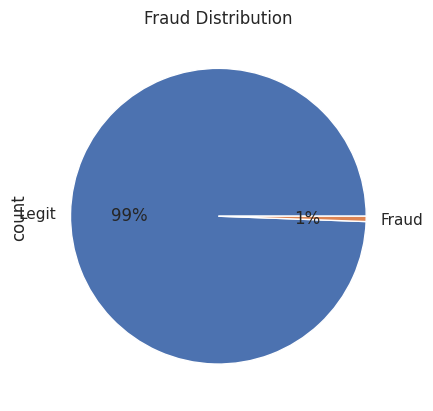

In [43]:
#1. Fraud Distribution (Target Class)

df_train['is_fraud'].value_counts().plot.pie(
    labels=['Legit', 'Fraud'],
    autopct='%0.0f%%'
)
plt.title("Fraud Distribution")
plt.show()

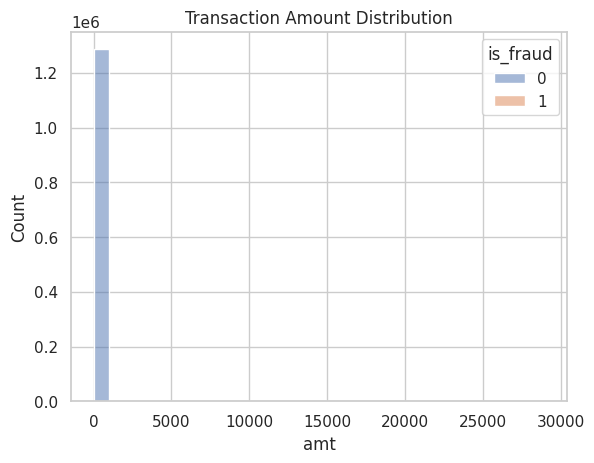

In [45]:
#2. Transaction Amount Analysis

sns.histplot(data=df_train, x='amt', hue='is_fraud', bins=30)
plt.title("Transaction Amount Distribution")
plt.show()

Transaction Amount

Fraud transactions often follow different patterns

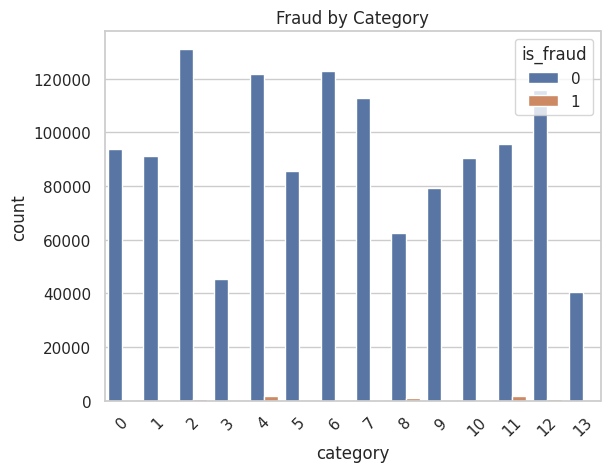

In [49]:
#3. Category Analysis

sns.countplot(data=df_train, x='category', hue='is_fraud')
plt.xticks(rotation=45)
plt.title("Fraud by Category")
plt.show()

Category Analysis

Certain categories (e.g., online shopping) have higher fraud rates

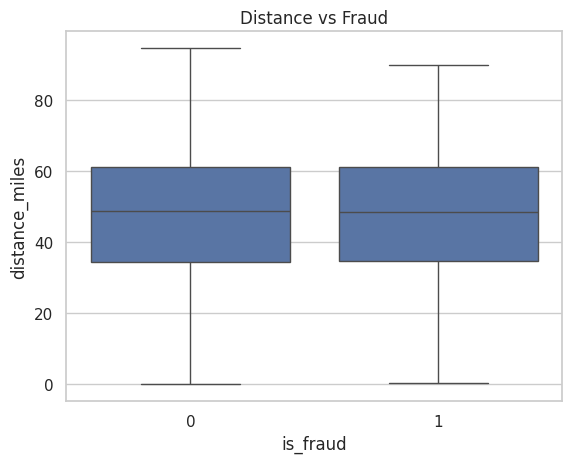

In [47]:
#4. Distance Analysis

sns.boxplot(x='is_fraud', y='distance_miles', data=df_train)
plt.title("Distance vs Fraud")
plt.show()

Distance Analysis

Fraud often occurs at unusual distances

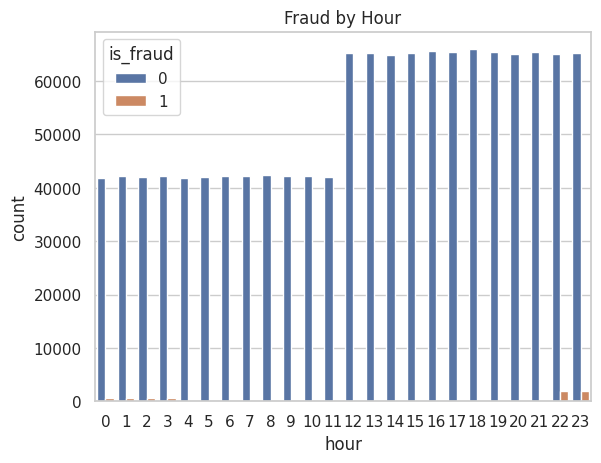

In [48]:
#5. Time Pattern Analysis

sns.countplot(x='hour', hue='is_fraud', data=df_train)
plt.title("Fraud by Hour")
plt.show()

**Key Insights**

1.Fraud transactions are rare but critical (~1%)

2.Late-night transactions show higher fraud probability

3.Online transaction categories are more vulnerable

4.Distance plays an important role in detecting suspicious activity

5.Age and behavioral patterns contribute to fraud detection

Conclusion

This project demonstrates how machine learning can effectively detect credit card fraud using behavioral patterns.

Feature engineering (especially distance and time features) plays a major role in improving model accuracy.